In [2]:
import pandas as pd
import numpy as np
import joblib
import shap
import matplotlib.pyplot as plt

print("Libraries loaded successfully")

Libraries loaded successfully


In [3]:
rf_model = joblib.load(
    "../models/random_forest_model.pkl"
)

print("Model loaded successfully")

Model loaded successfully


In [4]:
master_df = pd.read_csv(
    "../data/processed/featured_dataset.csv"
)

master_df['DATE_TIME'] = pd.to_datetime(
    master_df['DATE_TIME']
)

display(master_df.head())

,DATE_TIME,PLANT_ID,SOURCE_KEY,DC_POWER,AC_POWER,DAILY_YIELD,TOTAL_YIELD,AMBIENT_TEMPERATURE,MODULE_TEMPERATURE,IRRADIATION,HOUR,DAY,MONTH,DAY_OF_WEEK,WEEK_OF_YEAR,IS_PEAK_HOUR,TEMP_DIFFERENCE,IRRADIATION_EFFICIENCY,PREVIOUS_AC_POWER,ROLLING_MEAN_AC_POWER
0,2020-05-15,4136001,LYwnQax7tkwH5Cb,0.0,0.0,1872.500000,1.794959e+09,27.004764,25.060789,0.0,0,15,5,4,20,0,-1.943975,0.0,0.0,0.0
1,2020-05-15,4136001,LlT2YUhhzqhg5Sw,0.0,0.0,1094.357143,2.825928e+08,27.004764,25.060789,0.0,0,15,5,4,20,0,-1.943975,0.0,0.0,0.0
2,2020-05-15,4136001,Mx2yZCDsyf6DPfv,0.0,0.0,5692.200000,2.453646e+06,27.004764,25.060789,0.0,0,15,5,4,20,0,-1.943975,0.0,0.0,0.0
3,2020-05-15,4136001,NgDl19wMapZy17u,0.0,0.0,1866.200000,1.115126e+08,27.004764,25.060789,0.0,0,15,5,4,20,0,-1.943975,0.0,0.0,0.0
4,2020-05-15,4136001,PeE6FRyGXUgsRhN,0.0,0.0,651.200000,1.348351e+09,27.004764,25.060789,0.0,0,15,5,4,20,0,-1.943975,0.0,0.0,0.0


In [5]:
features_df = master_df.drop(
    columns=[
        'DATE_TIME',
        'SOURCE_KEY',
        'AC_POWER',
        'DC_POWER'
    ]
)

target = master_df['AC_POWER']

print(features_df.columns)

Index(['PLANT_ID', 'DAILY_YIELD', 'TOTAL_YIELD', 'AMBIENT_TEMPERATURE',
       'MODULE_TEMPERATURE', 'IRRADIATION', 'HOUR', 'DAY', 'MONTH',
       'DAY_OF_WEEK', 'WEEK_OF_YEAR', 'IS_PEAK_HOUR', 'TEMP_DIFFERENCE',
       'IRRADIATION_EFFICIENCY', 'PREVIOUS_AC_POWER', 'ROLLING_MEAN_AC_POWER'],
      dtype='str')


In [6]:
sample_features = features_df.sample(
    100,
    random_state=42
)

In [7]:
explainer = shap.TreeExplainer(
    rf_model
)

shap_values = explainer.shap_values(
    sample_features
)

print("SHAP values generated successfully")

SHAP values generated successfully


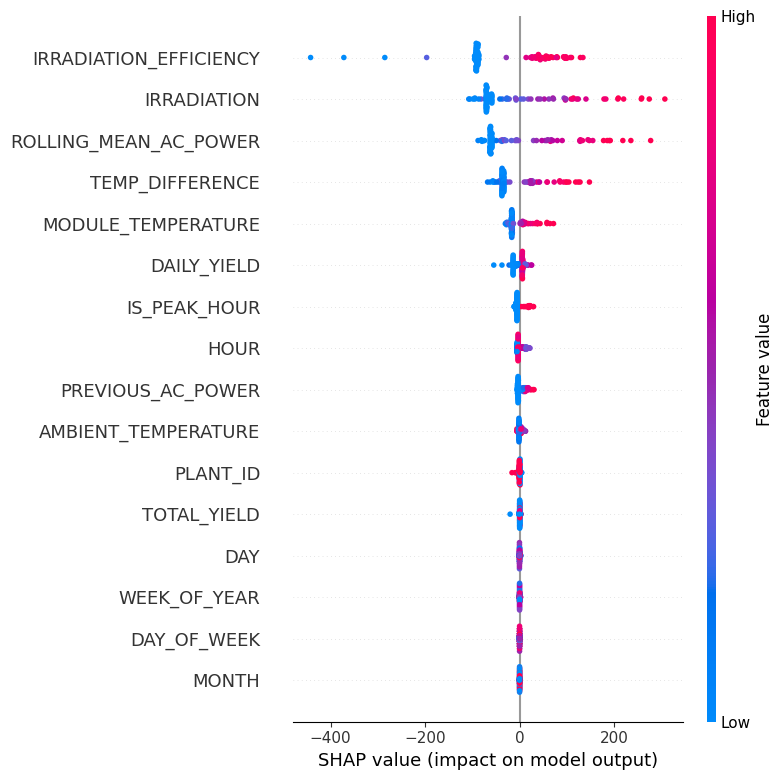

In [8]:
shap.summary_plot(
    shap_values,
    sample_features
)

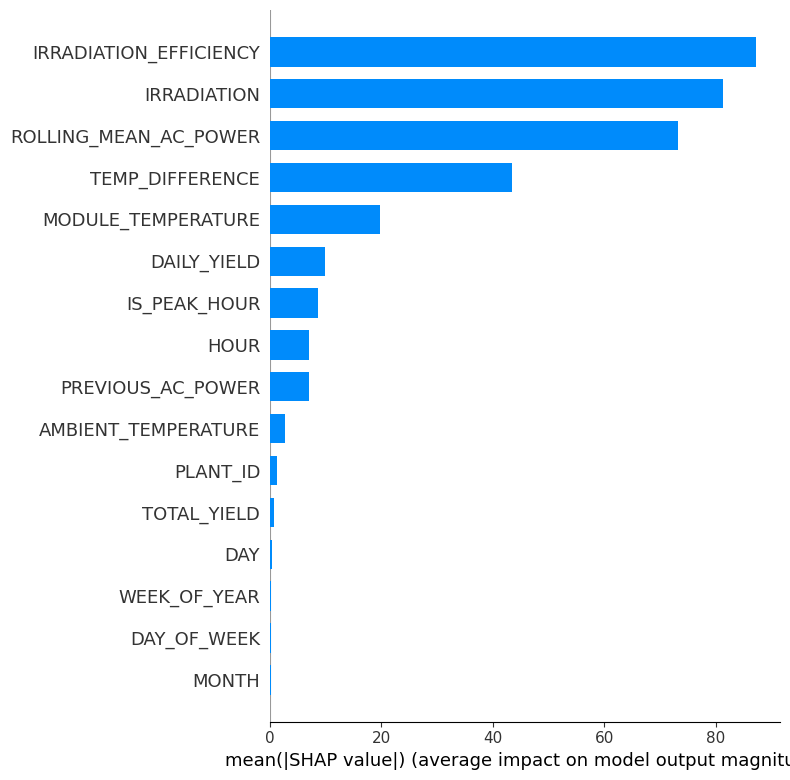

In [9]:
shap.summary_plot(
    shap_values,
    sample_features,
    plot_type="bar"
)

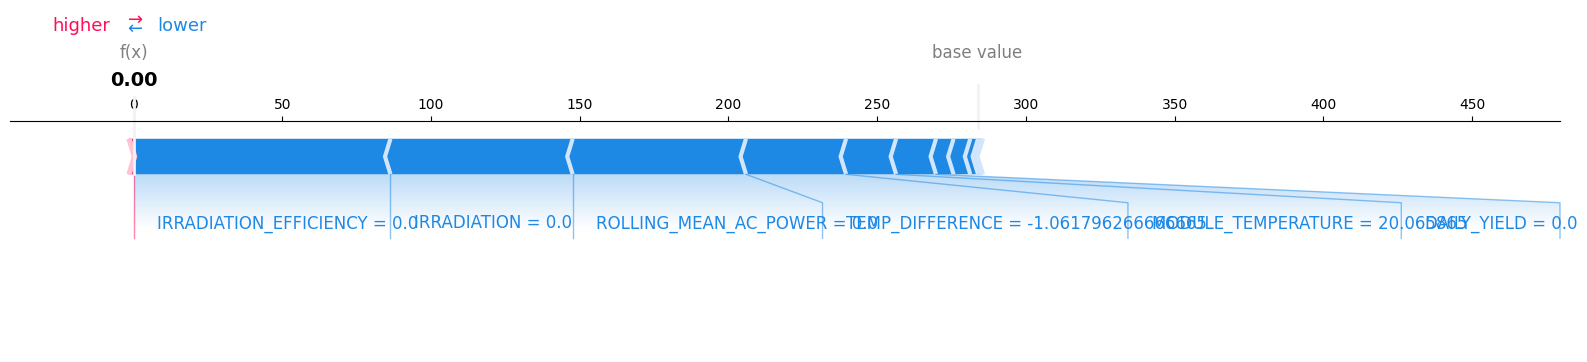

In [10]:
sample_row = sample_features.iloc[0]

shap.force_plot(

    explainer.expected_value,

    shap_values[0],

    sample_row,

    matplotlib=True
)